In [49]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !git pull
    
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
sys.path.append(str(Path.cwd().parent))
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
from scipy.ndimage import gaussian_filter1d
import utils
from utils import *
sns.set_context("poster")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

plt.rcParams['figure.dpi'] = 100 #

PyTorch: 2.10.0+cu128
CUDA available: False


## Load Data to evaluate model

In [50]:
project_root = Path.cwd().parent
models_dir = "saved_models"
data_dir = project_root / "Data"

In [51]:
file_path = data_dir / "PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz"
data_test   = np.load(file_path, allow_pickle=True)
stim_rs        = data_test["stim"]
spktimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)

In [52]:
dt = 1e-4
# stimulus frames are at 60 Hz
# CBEM runs at 0.1 ms bins, so we upsample stimulus and re-bin spikes from spike times
dt_stim = 1 / 60.0
trial_dur_s = stim_rs.shape[1] * dt_stim

# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                           presamples=presamples, postsamples=postsamples, 
                                           n_trials=len(spktimes_rs), 
                                        T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)


spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]


psth_hz = spk_test.mean(axis=0) / dt   # [T] in Hz
psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=int(0.02 / dt))  # 20 ms smoothing



In [53]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [54]:
## LOAD trained model
# ckpt_full = torch.load(f"{models_dir}/fuck_yeah_gbar200.pt", map_location=device)
ckpt_full = torch.load(f"{models_dir}/fuck_yeah.pt", map_location=device)

trained = CBEM_trials(binsize_s=ckpt_full["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_full["model_state_dict"]["B_cond"].shape[0]
trained._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

trained.load_state_dict(ckpt_full["model_state_dict"])
trained.eval()

steps_hist = ckpt_full.get("steps_hist", None)
loss_hist  = ckpt_full.get("loss_hist", None)

##Load Linear model
ckpt_linear = torch.load(f"{models_dir}/lin_model.pt", map_location=device)

cbem_lin = CBEM_linear(binsize_s=ckpt_linear["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_linear["model_state_dict"]["B_cond"].shape[0]
cbem_lin._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

cbem_lin.load_state_dict(ckpt_linear["model_state_dict"])
cbem_lin.eval()


CBEM_linear()

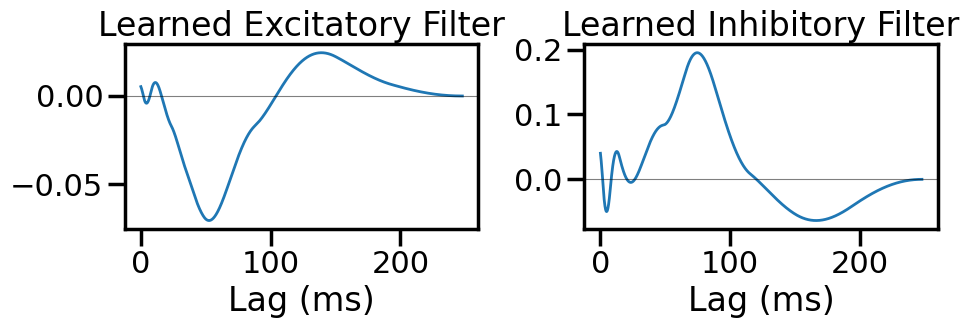

In [55]:
# Learned conductance filters in time domain
B = trained.B_cond.detach().cpu()   # [D, 2]
np.savez("B_trained", B)
W_orth = B[:-1, :]                  # drop bias row

B_orth_t = torch.as_tensor(B_orth, dtype=W_orth.dtype)
filters = B_orth_t @ W_orth            # [L, 2]

t_ms = np.arange(filters.shape[0]) * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(t_ms, filters[:, 0].numpy(), lw=2.0)
axes[0].set_title('Learned Excitatory Filter')
axes[0].set_xlabel('Lag (ms)')

axes[1].plot(t_ms, filters[:, 1].numpy(), lw=2.0)
axes[1].set_title('Learned Inhibitory Filter')
axes[1].set_xlabel('Lag (ms)')

for ax in axes:
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## Evaluate trained model

In [56]:
##Design Matrix test stim
stim_test_t = torch.as_tensor(stimulus_test, dtype=torch.float32, device=device)

# stimulus_t: [B, T]
# basis_t: [L, P]
X_test_tr = [
    convolveStimulusWithBasis_torch(stim_test_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_test.shape[0])
]
X_test = torch.stack(X_test_tr, dim=0)  # [B,T,D]
print('X_full:', X_test.shape)


def simulate_model(trained, X_test):
    ## FULL MODEL
    with torch.no_grad():
        rate_test, aux = trained(X_test)  # [B,T]
        
    B = X_test.shape[0]
    T0 = 500
    Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)  # [B,T0]
    sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0).detach().cpu().numpy()
    # sps: [B,T] in {0,1}
    B, T = sps_t.shape
    

    return rate_test, aux, sps_t

rate_test, aux, sps_t = simulate_model(trained, X_test)

# Build spike times (ms) per trial for eventplot
spkTimes_ms_by_trial = [
        np.where(sps_t[b, :] > 0)[0] * dt * 1e3
        for b in range(rate_test.shape[0])]
## LIN MODEL STATS
with torch.no_grad():
    psth_lin, aux_lin = cbem_lin(X_test)  # [B,T]
    
    


X_full: torch.Size([6, 100000, 11])


In [57]:
trained.g_l, trained.E_l, trained.gbar

(tensor(200.), tensor(-60.), tensor([80., 80.]))

In [58]:
rate_hat = rate_test.detach().cpu()
rate_lin = psth_lin.detach().cpu()

rate_hat = gaussian_filter1d(rate_hat[0], sigma=max(1, int(0.02 / dt)))  # 20 ms
rate_lin = gaussian_filter1d(rate_lin[0], sigma=max(1, int(0.02 / dt)))  # 20 ms

In [59]:
mean_rate_og = rate_hat.mean().item()
mean_rate_og

7.128125190734863

In [60]:
gs = aux['gs']
Vm = aux['V']
gs.shape, Vm.shape

(torch.Size([6, 100000, 2]), torch.Size([6, 100000]))

In [61]:
dt_s = 1e-4
trial = 1
L = 100000

Vm_np = Vm.detach().cpu().numpy() if hasattr(Vm, "detach") else Vm
t_ms = np.arange(L) * dt_s * 1e3

spk_idx = np.where(sps_t[trial, :L] > 0)[0]
spk_ms  = spk_idx * dt_s * 1e3

Vm0 = Vm_np[trial, :L]
Vm_at_spk = Vm0[spk_idx]



# make each spike a short tick starting at Vm(t_spike)


## Conductance -> current -> ATP

$g(t) \to I_{ion}(t) \to Q_{ion} \to N_{ions} \to ATP$
- Synpatic currents

    $I_{exc}(t) = g_{exc}(t) * (E_{exc} - V_m(t))$ 

    and 

    $I_{inh}(t) = g_{inh}(t) * (E_{inh} - V_m(t))$

    Using $E_{exc} = 0 mV$ and $E_{inh} = -80 mv$
- Leak current

    $I_{leak}(t) = g_{leak} * (E_{leak} - V_m(t))$
- Spiking currents


In [62]:
import torch

E_CHARGE = 1.602176634e-19  # C


def sodium_conductance_from_total(g_syn, E_syn, E_Na=60.0, E_K=-80.0):
    """
    g_syn: total conductance [B,T] or compatible, in nS
    E_syn, E_Na, E_K: mV
    returns g_Na in nS
    """
    frac_na = (E_syn - E_K) / (E_Na - E_K)
    return g_syn * frac_na


def sodium_current_from_total(g_syn, Vm, E_syn, E_Na=60.0, E_K=-80.0):
    """
    g_syn: nS
    Vm: mV
    returns I_Na in pA
    """
    g_Na = sodium_conductance_from_total(g_syn, E_syn=E_syn, E_Na=E_Na, E_K=E_K)
    I_Na = g_Na * (E_Na - Vm)   # pA
    return I_Na


def inward_charge_from_current(I, dt):
    """
    I in pA, dt in s
    Assumes inward current is positive under your sign convention.
    Returns charge in Coulombs.
    """
    # I_in = torch.clamp(I, min=0.0)
    Q = (I * dt * 1e-12).sum(dim=1)
    return Q


def atp_from_na_charge(Q_Na):
    """
    Q_Na in Coulombs
    returns ATP molecule count
    """
    N_Na = Q_Na / E_CHARGE
    ATP = N_Na / 3.0
    return ATP

In [63]:
I_Na_exc = sodium_current_from_total(gs[..., 0], Vm, E_syn=0.0, E_Na=60.0, E_K=-80.0)
Q_Na_exc = inward_charge_from_current(I_Na_exc, dt)
ATP_exc = atp_from_na_charge(Q_Na_exc)

I_Na_leak = sodium_current_from_total(trained.g_l, Vm, E_syn=-60.0, E_Na=60.0, E_K=-80.0)
Q_Na_leak = inward_charge_from_current(I_Na_leak, dt)
ATP_leak = atp_from_na_charge(Q_Na_leak)

ATP_exc, ATP_leak

(tensor([1.3390e+10, 1.3390e+10, 1.3390e+10, 1.3390e+10, 1.3390e+10, 1.3390e+10]),
 tensor([7.0568e+10, 7.0568e+10, 7.0568e+10, 7.0568e+10, 7.0568e+10, 7.0568e+10]))

In [117]:
g_l_span = torch.linspace(100, 300, 20, device=trained.g_l.device, dtype=trained.g_l.dtype)

results = []
g_l_orig = trained.g_l.clone()

for g_l_val in g_l_span:
    with torch.no_grad():
        trained.g_l.fill_(g_l_val)

        rate_test, aux = trained(X_test)

        B = X_test.shape[0]
        T0 = 500
        Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)
        sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0)

        gs = aux["gs"]       # [B,T,2]
        Vm = aux["V"]        # [B,T]

        # --- Excitatory Na current / ATP ---
        I_Na_exc = sodium_current_from_total(
            gs[..., 0], Vm,
            E_syn=0.0,
            E_Na=60.0,
            E_K=-80.0
        )
        Q_Na_exc = inward_charge_from_current(I_Na_exc, dt)
        ATP_exc = atp_from_na_charge(Q_Na_exc) *3

        # --- Leak Na current / ATP ---
        I_Na_leak = sodium_current_from_total(
            g_l_val, Vm,
            E_syn=-60.0,
            E_Na=60.0,
            E_K=-80.0
        )
        Q_Na_leak = inward_charge_from_current(I_Na_leak, dt)
        ATP_leak = atp_from_na_charge(Q_Na_leak) # * 0.7

        # --- Spikes ---
        spike_counts = sps_t.sum(dim=1)                     # [B]
        rate_hz_trial = spike_counts / (sps_t.shape[1] * dt)

        cost_spike = 4e8                                   # ATP molecules / spike
        ATP_spike = cost_spike * spike_counts.float()      # [B]

        ATP_total = ATP_exc + ATP_leak + ATP_spike

        ATP_total_per_spike = torch.full_like(ATP_total, float("nan"))
        mask = spike_counts > 0
        ATP_total_per_spike[mask] = ATP_total[mask] / spike_counts[mask]

        results.append({
            "g_l": float(g_l_val.item()),
            "cost_spike": cost_spike,
            "mean_ATP_exc": ATP_exc.mean().item(),
            "mean_ATP_leak": ATP_leak.mean().item(),
            "mean_ATP_spike": ATP_spike.mean().item(),
            "mean_ATP_total": ATP_total.mean().item(),
            "mean_ATP_per_spike": torch.nanmean(ATP_total_per_spike).item(),
            "mean_spike_count": spike_counts.float().mean().item(),
            "mean_rate_hz": rate_hz_trial.mean().item(),
            "mean_Vm": Vm.mean().item(),
            "std_Vm": Vm.std().item(),
            "mean_g_exc": gs[..., 0].mean().item(),
            "mean_g_inh": gs[..., 1].mean().item(),
            "mean_Q_Na_exc": Q_Na_exc.mean().item(),
            "mean_Q_Na_leak": Q_Na_leak.mean().item(),
        })

with torch.no_grad():
    trained.g_l.copy_(g_l_orig)

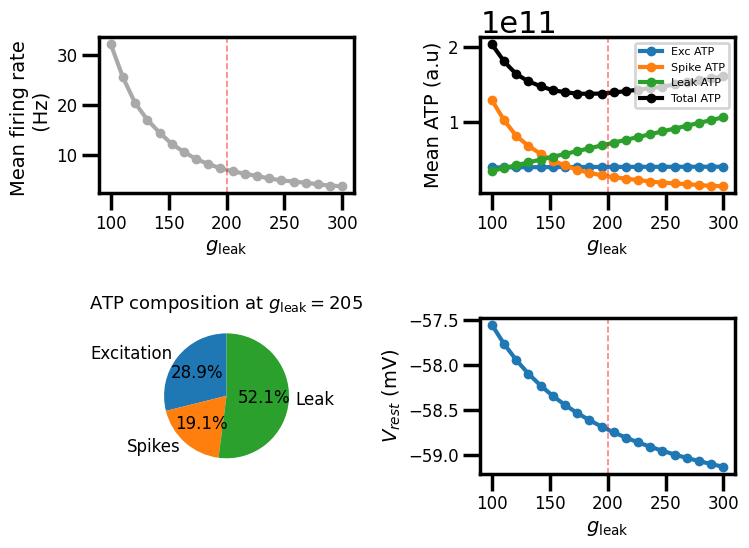

In [118]:
g_l_vals = np.array([r["g_l"] for r in results])
mean_rate = np.array([r["mean_rate_hz"] for r in results])
mean_ATP_exc = np.array([r["mean_ATP_exc"] for r in results])
mean_ATP_leak = np.array([r["mean_ATP_leak"] for r in results])
mean_ATP_spike = np.array([r["mean_ATP_spike"] for r in results])
mean_ATP_total = np.array([r["mean_ATP_total"] for r in results])
mean_Vm = np.array([r["mean_Vm"] for r in results])

msize=6
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
sns.set_palette("dark")
axes[0, 0].plot(g_l_vals, mean_rate, '-o',  markersize=msize, c='darkgray')
axes[0, 0].set_ylabel("Mean firing rate \n (Hz)", fontsize=14)

axes[0, 1].plot(g_l_vals, mean_ATP_exc, '-o',  markersize=msize,  label="Exc ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_spike,'-o',  markersize=msize,    label="Spike ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_leak,  '-o',  markersize=msize,       label="Leak ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_total,'-o',  markersize=msize, c='k', label="Total ATP")
axes[0, 1].set_ylabel("Mean ATP (a.u)", fontsize=14)
axes[0, 1].legend(loc='upper right', fontsize=8)

# --- bottom-left: pie chart at one selected g_leak ---
idx = len(g_l_vals) // 2   # middle g_leak value

pie_vals = [
    mean_ATP_exc[idx],
    mean_ATP_spike[idx],
    mean_ATP_leak[idx],
]
pie_labels = ["Excitation", "Spikes", "Leak"]
sns.set_palette("tab10")
axes[1, 0].pie(
    pie_vals,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12}
)
axes[1, 0].set_title(fr"ATP composition at $g_{{\mathrm{{leak}}}}={g_l_vals[idx]:.0f}$", fontsize=13)

axes[1, 1].plot(g_l_vals, mean_Vm, 'o-', markersize=msize)
axes[1, 1].set_ylabel("$V_{rest}$ (mV)", fontsize=14)

for ax in [axes[0, 0], axes[0, 1], axes[1, 1]]:
    ax.set_xlabel(r"$g_{\mathrm{leak}}$", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.axvline(200, ymin=0,ls='--', c='r', alpha=0.5, lw=1.2)

fig.tight_layout()
fig.savefig("g_leak_span_with_pie.png", bbox_inches="tight", dpi=300)
plt.show()

In [119]:
@torch.no_grad()
def mean_rate_with_exc_scale_from_aux(trained, aux, exc_scale):
    """
    Starting from the already-computed conductances aux["gs"] for a given g_l,
    scale excitation only, then recompute V and firing rate.

    Returns
    -------
    mean_rate : float
    rate_scaled : torch.Tensor [B,T]
    V_scaled : torch.Tensor [B,T]
    gs_scaled : torch.Tensor [B,T,2]
    """
    gs_scaled = aux["gs"].clone()
    gs_scaled[..., 0] *= exc_scale   # scale excitation only

    V_scaled = trained.voltage(gs_scaled)
    rate_scaled = 1e-4 + firingRateNonlinearity(
        V_scaled, trained.alpha, trained.mu, trained.beta
    )
    return rate_scaled.mean().item(), rate_scaled, V_scaled, gs_scaled


@torch.no_grad()
def solve_exc_scale_from_aux(
    trained,
    aux,
    target_rate_hz,
    s_lo=0.1,
    s_hi=20.0,
    n_iter=40
):
    """
    Bisection solve for the excitation scale that restores target mean rate.
    Uses deterministic rate, not stochastic spikes.
    """
    def f(s):
        mean_r, _, _, _ = mean_rate_with_exc_scale_from_aux(trained, aux, s)
        return mean_r - target_rate_hz

    flo = f(s_lo)
    fhi = f(s_hi)

    if flo * fhi > 0:
        raise RuntimeError(
            f"Target not bracketed: f({s_lo})={flo:.4f}, f({s_hi})={fhi:.4f}. "
            "Try increasing s_hi or decreasing s_lo."
        )

    lo, hi = s_lo, s_hi
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        fm = f(mid)

        if flo * fm <= 0:
            hi = mid
            fhi = fm
        else:
            lo = mid
            flo = fm

    return 0.5 * (lo + hi)

@torch.no_grad()
def simulate_spikes_from_rate(rate_hz, dt, seed=0, eps=0.0):
    """
    rate_hz : [B,T] firing rate in Hz
    dt      : bin size in seconds

    Returns
    -------
    sps : [B,T] in {0,1}
    """
    lam = rate_hz * dt                    # expected spikes/bin
    p = -torch.expm1(-lam)                # stable 1 - exp(-lam)

    if eps > 0:
        p = p.clamp(min=eps, max=1.0 - eps)
    else:
        p = p.clamp(min=0.0, max=1.0)

    gen = torch.Generator(device=rate_hz.device)
    gen.manual_seed(int(seed))
    rs = torch.rand(rate_hz.shape, generator=gen, device=rate_hz.device, dtype=rate_hz.dtype)

    sps = (rs < p).to(rate_hz.dtype)
    return sps


In [120]:


# =========================================================
# 3) Sweep g_l and solve compensating excitatory scale
# =========================================================
g_l_span = torch.linspace(
    100, 300, 20,
    device=trained.g_l.device,
    dtype=trained.g_l.dtype
)

results = []

for g_l_val in g_l_span:
    with torch.no_grad():
        # -------------------------
        # Uncompensated model
        # -------------------------
        trained.g_l.fill_(g_l_val)

        rate_pert, aux = trained(X_test)
        mean_rate_p = rate_pert.mean().item()
        diff_rate = mean_rate_p - mean_rate_og

        # -------------------------
        # Solve excitation scale
        # -------------------------
        s_exc = solve_exc_scale_from_aux(
            trained,
            aux,
            mean_rate_og,
            s_lo=0.1,
            s_hi=20.0,
            n_iter=40
        )

        # -------------------------
        # Evaluate compensated state
        # -------------------------
        mean_rate_c, rate_c, V_c, gs_c = mean_rate_with_exc_scale_from_aux(
            trained, aux, s_exc
        )
        sps_c = simulate_spikes_from_rate(rate_c, dt, seed=0)   # [B,T]

        spike_counts_c = sps_c.sum(dim=1)                       # [B]
        rate_hz_trial_c = spike_counts_c / (sps_c.shape[1] * dt)
        ATP_spike_c = cost_spike * spike_counts_c.float()       # [B]
        # cost_spike = 4e8 
        ## ADD ATP spike cost
        # -------------------------
        # ATP terms under compensation
        # -------------------------
        I_Na_exc_c = sodium_current_from_total(
            gs_c[..., 0], V_c,
            E_syn=0.0, E_Na=60.0, E_K=-80.0
        )
        Q_Na_exc_c = inward_charge_from_current(I_Na_exc_c, dt)
        ATP_exc_c = atp_from_na_charge(Q_Na_exc_c) *3

        I_Na_leak_c = sodium_current_from_total(
            g_l_val, V_c,
            E_syn=-60.0, E_Na=60.0, E_K=-80.0
        )
        Q_Na_leak_c = inward_charge_from_current(I_Na_leak_c, dt)
        ATP_leak_c = atp_from_na_charge(Q_Na_leak_c)

        ATP_total_c = ATP_exc_c + ATP_leak_c + ATP_spike_c

        results.append({
            "g_l": float(g_l_val.item()),

            "mean_rate_uncomp": float(mean_rate_p),
            "diff_rate_uncomp": float(diff_rate),

            "exc_scale_star": float(s_exc),
            "mean_rate_comp": float(mean_rate_c),

            "mean_ATP_exc_comp": float(ATP_exc_c.mean().item()),
            "mean_ATP_leak_comp": float(ATP_leak_c.mean().item()),
            "mean_ATP_total_comp": float(ATP_total_c.mean().item()),
            
            "mean_ATP_spike_comp": float(ATP_spike_c.mean().item()),
            "mean_ATP_total_comp": float(ATP_total_c.mean().item()),
            "mean_spike_count_comp": float(spike_counts_c.float().mean().item()),
            "mean_rate_spikes_comp": float(rate_hz_trial_c.mean().item()),

            "mean_Vm_comp": float(V_c.mean().item()),
            "std_Vm_comp": float(V_c.std().item()),
            "mean_g_exc_comp": float(gs_c[..., 0].mean().item()),
            "mean_g_inh_comp": float(gs_c[..., 1].mean().item()),
        })

# restore original leak
with torch.no_grad():
    trained.g_l.copy_(g_l_orig)


# =========================================================
# 4) Convert to arrays for plotting
# =========================================================
g_l_vals = np.array([r["g_l"] for r in results])

mean_rate_uncomp = np.array([r["mean_rate_uncomp"] for r in results])
mean_rate_comp   = np.array([r["mean_rate_comp"] for r in results])

exc_scale_star   = np.array([r["exc_scale_star"] for r in results])

mean_ATP_exc_comp   = np.array([r["mean_ATP_exc_comp"] for r in results])
mean_ATP_leak_comp  = np.array([r["mean_ATP_leak_comp"] for r in results])
mean_ATP_spike_comp = np.array([r["mean_ATP_spike_comp"] for r in results])
mean_ATP_total_comp = np.array([r["mean_ATP_total_comp"] for r in results])

mean_Vm_comp    = np.array([r["mean_Vm_comp"] for r in results])
mean_g_exc_comp = np.array([r["mean_g_exc_comp"] for r in results])
mean_g_inh_comp = np.array([r["mean_g_inh_comp"] for r in results])



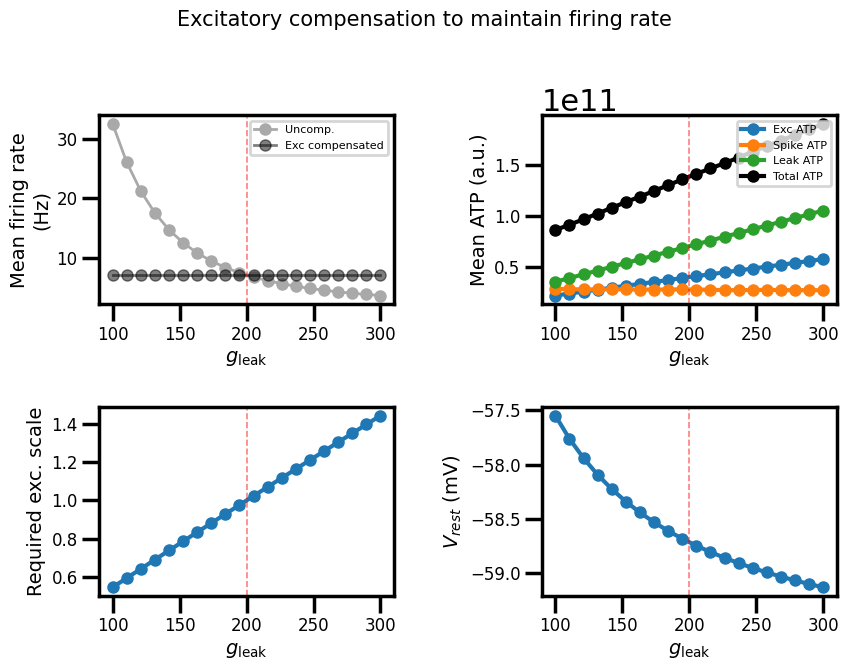

In [121]:

# =========================================================
# 5) Plot: similar 2x2 summary figure
# =========================================================
# sns.set_palette("dark")
msize = 8
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# -------------------------
# top-left: firing rate
# -------------------------
axes[0, 0].plot(g_l_vals, mean_rate_uncomp, '-o',  c='darkgray', 
                markersize= msize, lw=2, label="Uncomp.")
axes[0, 0].plot(g_l_vals, mean_rate_comp, '-o',  c='k', alpha=0.5, 
                markersize= msize, lw=2, label="Exc compensated")
# axes[0, 0].axhline(mean_rate_og, ls='--', c='k', markersize= msize, alpha=0.7, lw=1.2, label="Target")
axes[0, 0].set_ylabel("Mean firing rate\n(Hz)", fontsize=14)
axes[0, 0].legend(fontsize=8)

# -------------------------
# top-right: ATP terms
# -------------------------
axes[0, 1].plot(g_l_vals, mean_ATP_exc_comp, '-o', markersize= msize, label="Exc ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_spike_comp, '-o', markersize= msize, label="Spike ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_leak_comp, '-o', markersize= msize, label="Leak ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_total_comp, '-o', markersize= msize, c='k', label="Total ATP")
axes[0, 1].set_ylabel("Mean ATP (a.u.)", fontsize=14)
axes[0, 1].legend(loc='upper right', fontsize=8)
# -------------------------
# bottom-right: required excitation scale
# -------------------------
axes[1, 0].plot(g_l_vals, exc_scale_star, '-o', markersize= msize,)
axes[1, 0].set_ylabel(r"Required exc. scale", fontsize=14)


axes[1, 1].plot(g_l_vals, mean_Vm, 'o-', markersize=msize)
axes[1, 1].set_ylabel("$V_{rest}$ (mV)", fontsize=14)
# shared styling
for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]:
    ax.set_xlabel(r"$g_{\mathrm{leak}}$", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.axvline(200, ymin=0, ls='--', c='r', alpha=0.5, lw=1.2)

fig.suptitle("Excitatory compensation to maintain firing rate", fontsize=15)
plt.tight_layout()
plt.show()


## To do:

- Clamp either `g_syn` or `fr_nl` to keep stable fr

In [122]:
@torch.no_grad()
def mean_rate_with_exc_scale_from_aux(trained, aux, exc_scale):
    gs_scaled = aux["gs"].clone()          # [B,T,2]
    gs_scaled[..., 0] *= exc_scale         # scale excitation only

    V_scaled = trained.voltage(gs_scaled)  # recompute voltage
    rate_scaled = 1e-4 + firingRateNonlinearity(
        V_scaled, trained.alpha, trained.mu, trained.beta
    )
    return rate_scaled.mean().item(), rate_scaled, V_scaled, gs_scaled

@torch.no_grad()
def solve_exc_scale_from_aux(trained, aux, target_rate_hz,
                             s_lo=0.1, s_hi=10.0, n_iter=40):
    def f(s):
        mean_r, _, _, _ = mean_rate_with_exc_scale_from_aux(trained, aux, s)
        return mean_r - target_rate_hz

    flo = f(s_lo)
    fhi = f(s_hi)

    if flo * fhi > 0:
        raise RuntimeError(
            f"Target not bracketed: f({s_lo})={flo:.4f}, f({s_hi})={fhi:.4f}"
        )

    lo, hi = s_lo, s_hi
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        fm = f(mid)

        if flo * fm <= 0:
            hi = mid
            fhi = fm
        else:
            lo = mid
            flo = fm

    return 0.5 * (lo + hi)

In [123]:
g_l_span = torch.linspace(100, 300, 20, device=trained.g_l.device, dtype=trained.g_l.dtype)

results = []
g_l_orig = trained.g_l.clone()

for g_l_val in g_l_span:
    with torch.no_grad():
        trained.g_l.fill_(g_l_val)

        # un-compensated model at this leak
        rate_pert, aux = trained(X_test)
        mean_rate_p = rate_pert.mean().item()
        diff_rate = mean_rate_p - mean_rate_og

        # solve excitation scale needed to restore original mean rate
        s_exc = solve_exc_scale_from_aux(
            trained, aux, mean_rate_og,
            s_lo=0.1, s_hi=20.0, n_iter=40
        )

        # evaluate compensated state
        mean_rate_c, rate_c, V_c, gs_c = mean_rate_with_exc_scale_from_aux(
            trained, aux, s_exc
        )

        I_Na_exc_c = sodium_current_from_total(gs_c[..., 0], V_c, E_syn=0.0, E_Na=60.0, E_K=-80.0)
        Q_Na_exc_c = inward_charge_from_current(I_Na_exc_c, dt)
        ATP_exc_c = atp_from_na_charge(Q_Na_exc_c)

        I_Na_leak_c = sodium_current_from_total(g_l_val, V_c, E_syn=-60.0, E_Na=60.0, E_K=-80.0)
        Q_Na_leak_c = inward_charge_from_current(I_Na_leak_c, dt)
        ATP_leak_c = atp_from_na_charge(Q_Na_leak_c)
        results.append({
            "g_l": float(g_l_val.item()),
            "mean_rate_uncomp": float(mean_rate_p),
            "diff_rate_uncomp": float(diff_rate),
            "exc_scale_star": float(s_exc),
            "mean_rate_comp": float(mean_rate_c),
            "mean_Vm_comp": float(V_c.mean().item()),
            "mean_g_exc_comp": float(gs_c[..., 0].mean().item()),
            "mean_g_inh_comp": float(gs_c[..., 1].mean().item()),
        })

with torch.no_grad():
    trained.g_l.copy_(g_l_orig)

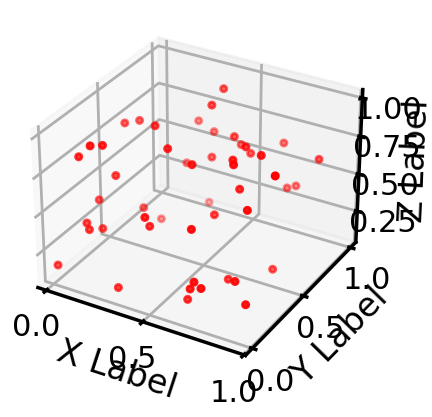

In [124]:
import matplotlib.pyplot as plt
import numpy as np

# Import the mplot3d toolkit
from mpl_toolkits.mplot3d import Axes3D

# Create data
# For a real application, you would use your own data
x = np.random.rand(50)
y = np.random.rand(50)
z = np.random.rand(50)

# Create a figure and a 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # or use ax = plt.axes(projection='3d')

# Plot the data
ax.scatter(x, y, z, c='r', marker='o') # 'c' for color, 'marker' for point style

# Set labels for axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# Display the plot
plt.show()
